In [1]:
# ================================================
# Phase 3 — Campaign Response Model
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_curve, auc, confusion_matrix, 
                             classification_report, roc_auc_score)
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# Load master data
master = pd.read_csv('../data/master_data.csv')

print("Data loaded!")
print("Shape:", master.shape)
print("\nColumns:", master.columns.tolist())

Data loaded!
Shape: (3834, 12)

Columns: ['CustomerID', 'response', 'n_comp', 'loyalty', 'nps', 'n_communications', 'Total_Spending', 'Purchase_Frequency', 'Recency', 'Unique_Products', 'Avg_Basket_Size', 'nps_group']


In [2]:
# ================================================
# Prepare Data for Modelling
# ================================================

# independent variables (X)
#  predict (y)

X = master[['Total_Spending', 
            'Purchase_Frequency',
            'Recency',
            'Unique_Products',
            'Avg_Basket_Size',
            'nps',
            'n_comp', 
            'n_communications',
            'loyalty']]

y = master['response']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures used:", X.columns.tolist())
print("\nResponse distribution:")
print(y.value_counts())
print(f"\nResponse rate: {y.mean()*100:.1f}%")

X shape: (3834, 9)
y shape: (3834,)

Features used: ['Total_Spending', 'Purchase_Frequency', 'Recency', 'Unique_Products', 'Avg_Basket_Size', 'nps', 'n_comp', 'n_communications', 'loyalty']

Response distribution:
response
0    2279
1    1555
Name: count, dtype: int64

Response rate: 40.6%


In [3]:
 # ================================================
#  Split Data Train and Test (80/20)
# ================================================

# Data split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,   
    random_state=42,  
    stratify=y       
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)
print(f"\nTrain response rate: {y_train.mean()*100:.1f}%")
print(f"Test response rate:  {y_test.mean()*100:.1f}%")

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Train size: (3067, 9)
Test size:  (767, 9)

Train response rate: 40.6%
Test response rate:  40.5%


In [4]:
# Create and train the model
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)


coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("=== Logistic Regression Coefficients ===")
print(coef_df.to_string(index=False))

=== Logistic Regression Coefficients ===
           Feature  Coefficient
               nps     0.469381
           loyalty     0.294151
  n_communications     0.225292
   Avg_Basket_Size     0.109862
           Recency     0.070189
Purchase_Frequency    -0.005625
   Unique_Products    -0.010112
    Total_Spending    -0.015243
            n_comp    -0.128917


In [5]:
# ================================================
 #  Check Multicollinearity (VIF)
# ================================================


# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(
                    X.values, i) 
                    for i in range(X.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False)

print("=== Variance Inflation Factor (VIF) ===")
print(vif_data.to_string(index=False))
print("\nRule:")
print("VIF < 5  → No multicollinearity ")
print("VIF 5-10 → Moderate ")
print("VIF > 10 → High multicollinearity")

=== Variance Inflation Factor (VIF) ===
           Feature      VIF
  n_communications 4.789639
               nps 3.434647
            n_comp 3.093679
Purchase_Frequency 3.081835
   Unique_Products 2.640685
           loyalty 2.220277
    Total_Spending 2.041252
           Recency 1.653861
   Avg_Basket_Size 1.495170

Rule:
VIF < 5  → No multicollinearity 
VIF 5-10 → Moderate 
VIF > 10 → High multicollinearity


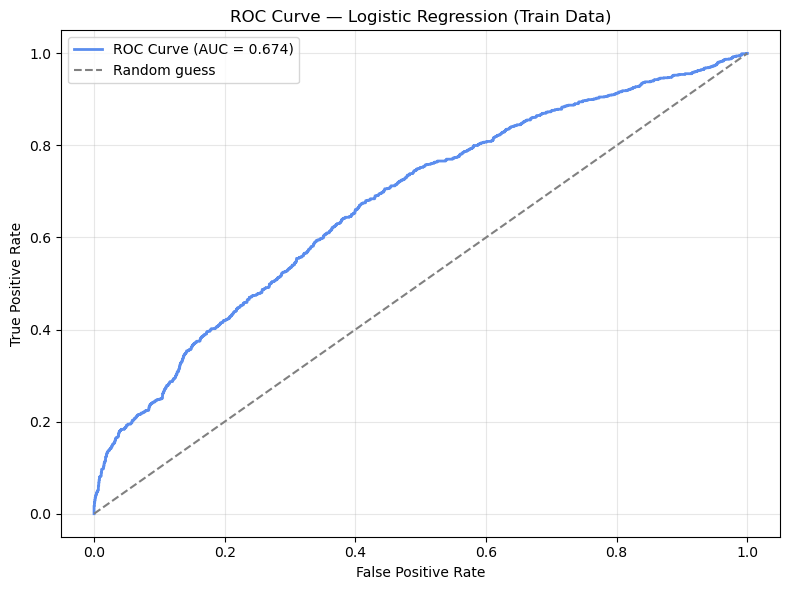

Train AUC: 0.674


In [6]:
# ================================================
# ROC Curve and AUC (Train Data)
# ================================================


# Get predicted probabilities
y_train_prob = log_model.predict_proba(X_train_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_train, y_train_prob)
train_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#5b8dee', linewidth=2,
         label=f'ROC Curve (AUC = {train_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', 
         linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (Train Data)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/roc_train.png', dpi=150)
plt.show()

print(f"Train AUC: {train_auc:.3f}")

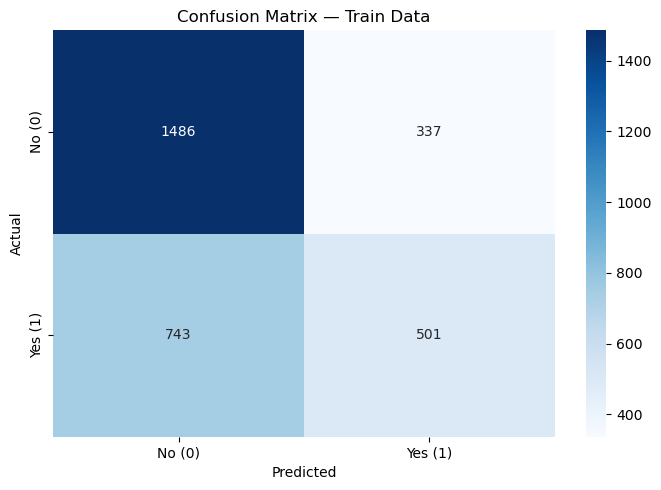

Accuracy:          0.648
Sensitivity:       0.403
Specificity:       0.815
Balanced Accuracy: 0.609


In [7]:
# ================================================
# Confusion Matrix (Train Data)
# ================================================

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import balanced_accuracy_score

# Predict on train data
y_train_pred = log_model.predict(X_train_scaled)

# Confusion matrix
cm = confusion_matrix(y_train, y_train_pred)

# Plot confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
plt.title('Confusion Matrix — Train Data')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../images/confusion_matrix_train.png', dpi=150)
plt.show()

# Metrics
tn, fp, fn, tp = cm.ravel()
accuracy     = (tp + tn) / (tp + tn + fp + fn)
sensitivity  = tp / (tp + fn)   
specificity  = tn / (tn + fp)
balanced_acc = balanced_accuracy_score(y_train, y_train_pred)

print(f"Accuracy:          {accuracy:.3f}")
print(f"Sensitivity:       {sensitivity:.3f}")
print(f"Specificity:       {specificity:.3f}")
print(f"Balanced Accuracy: {balanced_acc:.3f}")

Best threshold:  0.404
Sensitivity at best threshold: 0.629
Specificity at best threshold: 0.628


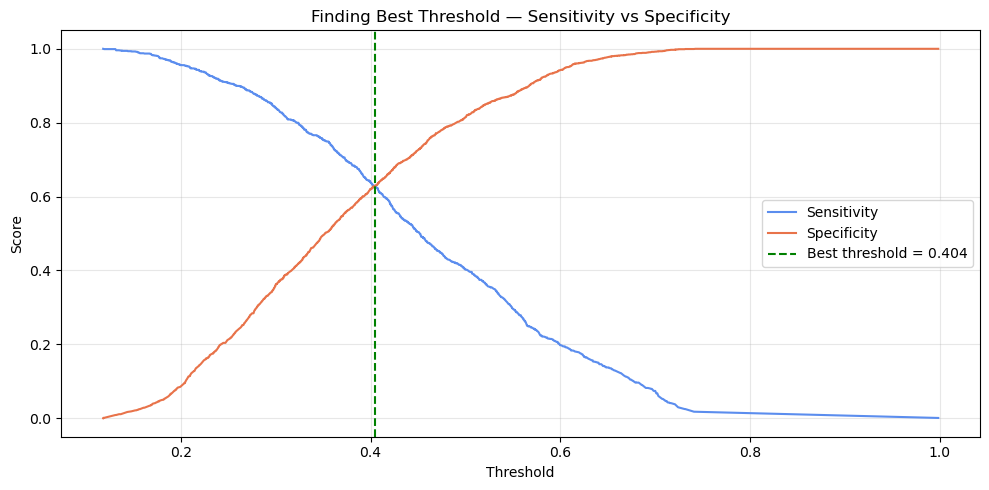

In [8]:
# ================================================
# Find Best Threshold
# ================================================

y_train_prob = log_model.predict_proba(X_train_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_train, y_train_prob)

differences = abs(tpr - (1 - fpr))
best_idx = differences.argmin()
best_threshold = thresholds[best_idx]

print(f"Best threshold:  {best_threshold:.3f}")
print(f"Sensitivity at best threshold: {tpr[best_idx]:.3f}")
print(f"Specificity at best threshold: {1-fpr[best_idx]:.3f}")


plt.figure(figsize=(10, 5))
plt.plot(thresholds, tpr[:-1] if len(tpr) > len(thresholds) 
         else tpr, label='Sensitivity', color='#5b8dee')
plt.plot(thresholds, 
         [1-f for f in fpr[:-1]] if len(fpr) > len(thresholds) 
         else [1-f for f in fpr], 
         label='Specificity', color='#e8734a')
plt.axvline(x=best_threshold, color='green', 
            linestyle='--', label=f'Best threshold = {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Finding Best Threshold — Sensitivity vs Specificity')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/threshold.png', dpi=150)
plt.show()

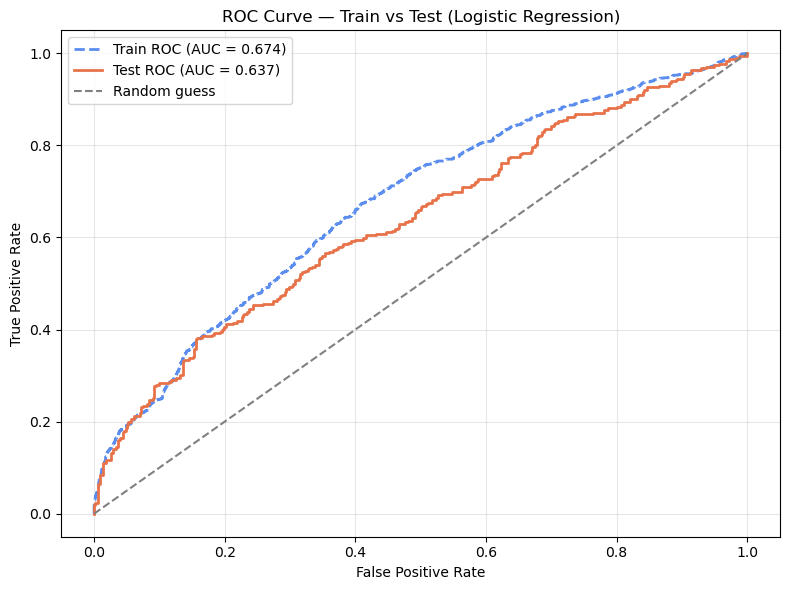

Train AUC: 0.674
Test AUC:  0.637
Difference: 0.037


In [9]:
# ================================================
# ROC Curve and AUC (Test Data)
# ================================================

# Get probabilities for test data
y_test_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve for test
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
test_auc = auc(fpr_test, tpr_test)

# Plot both train and test ROC together
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr,
         color='#5b8dee', linewidth=2,
         linestyle='--',
         label=f'Train ROC (AUC = {train_auc:.3f})')
plt.plot(fpr_test, tpr_test,
         color='#e8734a', linewidth=2,
         label=f'Test ROC (AUC = {test_auc:.3f})')
plt.plot([0, 1], [0, 1],
         color='gray', linestyle='--',
         label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Train vs Test (Logistic Regression)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../images/roc_train_vs_test.png', dpi=150)
plt.show()

print(f"Train AUC: {train_auc:.3f}")
print(f"Test AUC:  {test_auc:.3f}")
print(f"Difference: {abs(train_auc - test_auc):.3f}")

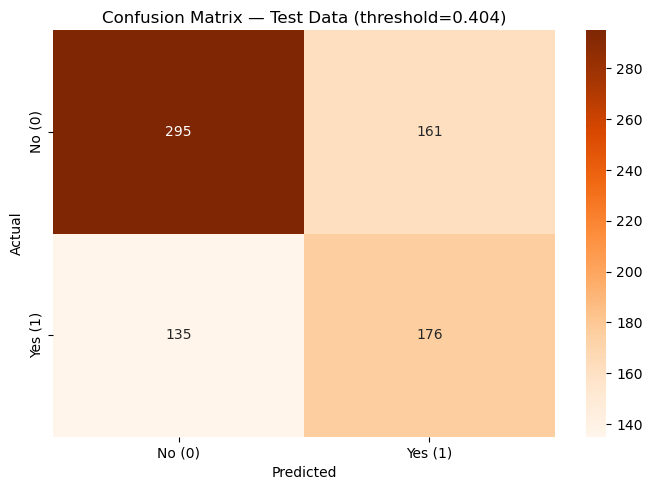

=== Test Data Metrics (at best threshold) ===
Accuracy:     0.614
Sensitivity: 0.815  |  Test Specificity: 0.647


In [ ]:
# ================================================
# Sensitivity and Specificity (Test Data)
# ================================================

# Apply best threshold to test predictions
y_test_pred_best = (y_test_prob >= best_threshold).astype(int)

# Confusion matrix 
cm_test = confusion_matrix(y_test, y_test_pred_best)

# Plot confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm_test, annot=True, fmt='d',
            cmap='Oranges',
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
plt.title(f'Confusion Matrix — Test Data (threshold={best_threshold:.3f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../images/confusion_matrix_test.png', dpi=150)
plt.show()

# Calculate metrics
tn, fp, fn, tp = cm_test.ravel()
accuracy_test     = (tp + tn) / (tp + tn + fp + fn)
sensitivity_test  = tp / (tp + fn)
specificity_test  = tn / (tn + fp)

print("=== Test Data Metrics (at best threshold) ===")
print(f"Accuracy:     {accuracy_test:.3f}")
print(f"Sensitivity: {specificity:.3f}  |  Test Specificity: {specificity_test:.3f}")